# PyTorch 학습 데모 - 회귀

목표(10~15분 데모):
1. `pred → loss → backward → step` 흐름을 **한 번에** 보여주기  
2. 학습률(lr) 크기에 따른 **수렴/발산** 감각 주기
> 강사가 실행/설명하는 용도입니다.


In [2]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(42)

## 0) 데이터 만들기 (선형 회귀: y = 2x + 1 + noise)
- “정답이 있는” 회귀 데이터를 인위적으로 만들어서
모델이 학습하면 w≈2, b≈1로 가는지 확인용

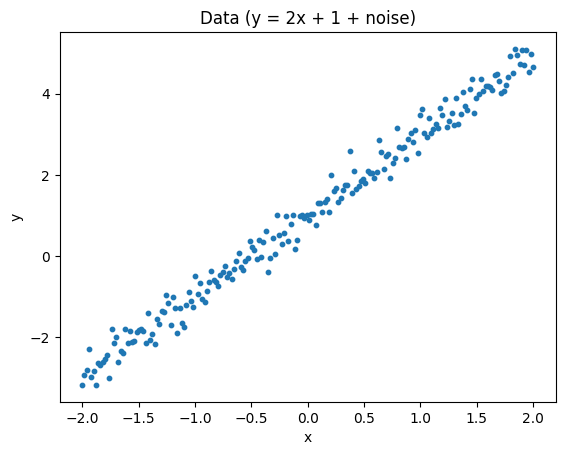

In [7]:
# y = 2x + 1 + noise (회귀 데이터)
n = 200
x = torch.linspace(-2, 2, n).unsqueeze(1)
y = 2.0 * x + 1.0 + torch.randn(n, 1) * 0.3

plt.figure()
plt.scatter(x.squeeze(1), y.squeeze(1), s=10)
plt.title("Data (y = 2x + 1 + noise)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

## 1) 핵심 학습 루프
- 예측 → 손실 → backward → step
- 학습률이 더 크면 한번에 더 많이 움직임 (학습률 = "보폭")
- 전체적으로 안정적으로 loss가 감소하는지 살펴보기

learned w≈1.982, b≈1.008


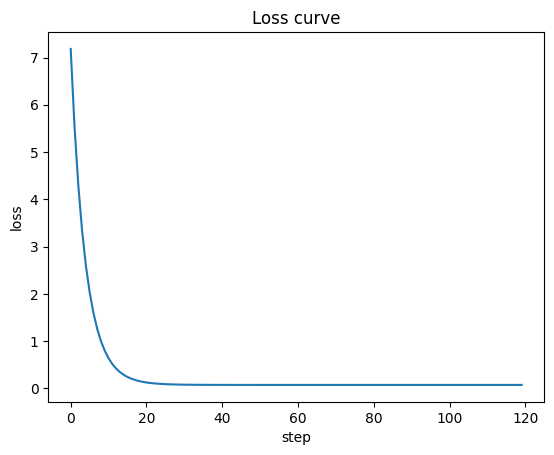

In [15]:
# ✅ 초압축 데모 2/2: 학습 루프 4줄 + lr 한 번만 바꿔보기
model = torch.nn.Linear(1, 1)          # y_hat = w*x + b
criterion = torch.nn.MSELoss()         # 평균제곱오차
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)  # lr 바꿔가며 시연 (0.5, 1로 각각 변경해보기)

steps = 120
losses = []

for _ in range(steps):
    pred = model(x)            # 1) 예측
    loss = criterion(pred, y)  # 2) 손실
    losses.append(loss.item())

    optimizer.zero_grad()      # (중요) 기울기 누적 방지
    loss.backward()            # 3) 기울기 계산
    optimizer.step()           # 4) 업데이트

w = model.weight.item()
b = model.bias.item()
print(f"learned w≈{w:.3f}, b≈{b:.3f}")

plt.figure()
plt.plot(losses)
plt.title("Loss curve")
plt.xlabel("step"); plt.ylabel("loss")
plt.show()
